# LLM-assisted signal detection in FAERS

### From spontaneous reports to a prioritized shortlist of potentially *unlabeled* adverse drug reactions

This notebook is the full report of the project — introduction, statistical modeling,
LLM use, and scoring — for the hackathon of the **2nd AI Workshop**, New York City.

| Section | Subtitle | Contents |
|---|---|---|
| 1 | Introduction | (1) Project goal, (2) what FAERS is, and (3) why an LLM |
| 2 | Data (Stage 0) | (1) What is actually in a FAERS report, and (2) the structure we analyze |
| 3 | MGPS & EBGM (Stage 1) | Statistical modeling of drug–PT disproportionality |
| 4 | PT triage (Stage 2) | FAERS records *adverse events*; we want *adverse reactions* — so which PTs are genuine clinical events at all? |
| 5 | Label comparison (Stage 3) | Matching each significant drug–PT pair against that drug's actual FDA label |
| 6 | Scoring (Stage 4) | Prioritizing the remaining PTs per drug across five criteria |
| 7 | Discussion | (1) What the pipeline achieves, (2) where it breaks, and (3) what comes next |

<br>

> **A note on AI assistance.** The analysis code and the text of this report were drafted with an LLM (Claude Code) working against the actual data and codebase. Every stage was then reviewed, corrected, and edited by hand — the pipeline design, the statistical choices, the drug brand curation, and the interpretation of results are mine.



---
## 1. Introduction

### 1.1 The goal

Given the FDA Adverse Event Reporting System (FAERS), produce **for each drug a ranked shortlist of adverse events (AEs) that are (a) statistically disproportionate, (b) adverse drug reaction (ADR), (c) *not already on the drug's FDA label*, and (d) worth investigating further.**

Classical disproportionality analysis answers only (a) — for hundreds of thousands of pairs. What a reviewer needs is the handful of ADRs that could be a *new* safety signal.

### 1.2 What FAERS is

FAERS is the FDA's **spontaneous** adverse-event reporting database: reports arrive voluntarily from clinicians and patients, and through mandatory manufacturer channels. Three properties dictate what analysis is possible:

- **No denominator.** We never know how many people took the drug and were fine — so no incidence rate, no epidemiological relative risk.
- **No causality.** A report says only "this event happened to someone taking this drug."
- **Heavily confounded.** Multiple drugs per report, comorbidities, and reporting biases.

FAERS therefore cannot tell you a drug *causes* an event — only that the event is reported **disproportionately often** with it. That is a signal to investigate, not a conclusion.

### 1.3 The usual analysis: disproportionality on a 2×2 table

For every (drug, event) pair, collapse the whole database into a contingency table:

|  | **event = PT** | **event ≠ PT** | |
|---|---|---|---|
| **drug = D** | `a` | `b` | a+b |
| **drug ≠ D** | `c` | `d` | c+d |
| | a+c | b+d | N |

Under independence the expected count is `E = (a+b)(a+c)/N`, and `RR = a/E` is the raw signal. Every classical measure — **Proportional Reporting Ratio (PRR)** = `[a/(a+b)] / [c/(c+d)]`, **Reporting Odds Ratio (ROR)** = `(a/b) / (c/d) = ad/bc`, and **EBGM** (Gamma-Poisson Shrinker, DuMouchel 1999; see the [FDA data-mining white paper](https://www.fda.gov/science-research/data-mining/data-mining-fda-white-paper)) — is a function of this table. We use EBGM; see §3.

**Why raw RR/PRR is not enough:** most pairs have tiny counts. A pair seen twice against an expected count of 0.001 has an enormous PRR and means nothing. Empirical Bayes exists to shrink those away.

### 1.4 Where the LLM comes in

Disproportionality is a *statistical* filter. Everything after it has required a human expert reading MedDRA terms and FDA labels — and those are the judgments we hand to a frontier LLM:

| Judgment | Previously | Here |
|---|---|---|
| Is this PT even a clinical *reaction* (vs. a lab name, device complaint, medication error)? | expert triage | **Stage 2**, drug-agnostic categorization of every PT |
| Is it already described on *this drug's* label? | expert reads the SPL | **Stage 3**, hierarchical classification against the openFDA label |
| Is it severe / biologically plausible / literature-supported? | expert intuition | **Stage 4**, embedding-based semantic scoring |

**Models:** `gpt-4.1` (`temperature=0`, for reproducible labels) for Stages 2–3; `text-embedding-3-large` for the Stage 4 semantic axes. Stage 1 stays in R — **the LLM never touches the statistical analysis.**


---
## 2. Data (Stage 0) — What is in a FAERS report?

### 2.1 The seven files

Each FAERS quarterly release splits every report across seven tables, joined on `primaryid`. Only three of them carry what the pipeline needs:

| File | Contents | Used here? |
|---|---|---|
| `DEMO` | caseid, `caseversion`, `lit_ref` (literature citation), age, sex, etc. | **yes** |
| `DRUG` | **one row per drug on the report**: `prod_ai` (active ingredient), `role_cod`, dose, etc. | **yes** |
| `REAC` | **one row per reaction**: MedDRA `pt` | **yes** |
| `OUTC` | outcome codes (death, hospitalization, etc.) | no |
| `RPSR` | report source | no |
| `THER` | therapy start/end dates | no |
| `INDI` | indication for use | no |

**Data coverage: 2024Q1 – 2026Q1.**

### 2.2 The unit of analysis: a (drug, PT) pair

A single report lists **one or more drugs (active ingredients)** and **one or more PTs (adverse events)**. The analysis pairs every suspect drug on a report with every reaction on that report. **A pair is counted once per report**, so each cell of the 2×2 table counts *reports*.

### 2.3 MedDRA Preferred Terms (PT)

Reactions are coded as **MedDRA Preferred Terms** — one PT = one coded medical concept. But MedDRA is a *general* medical dictionary, not a list of adverse reactions. Its terms cover:

- signs, symptoms, and diagnoses — *Hepatic failure*, *Seizure*, *Rash*
- investigations (test names and results) — *Blood glucose increased*
- procedures — *Dialysis*
- therapeutic context, product complaints, and administrative terms — *Drug ineffective*, *Off label use*, *Product quality issue*

Separating the terms that could be an adverse reaction from the terms that intrinsically cannot is the entire motivation for Stage 2.

### 2.4 Processing and outputs

`step0_process_data.R` imports the quarterly ZIPs and applies three filters, in order:

1. **Deduplicate case versions.** Keep only the **latest `caseversion` per `caseid`**.
2. **Suspect drugs with a known ingredient.** `role_cod ∈ {PS, SS}` and `prod_ai` not missing.
3. **Cap bulk multi-drug reports.** Reports with **> 25** distinct suspect ingredients are dropped, since the many-to-many join would turn each one into hundreds of spurious drug–AE co-occurrences.

It writes three tables:

- **`drug_reac_pairs.csv`** — one row per (report, drug, PT). The input to the 2×2 counts in Stage 1.
- **`pair_features.csv`** — per (drug, PT): `n_reports` and **`median_suspects`**, the median number of suspect drugs on the reports carrying that pair (it counts the pair's own drug, so the minimum is 1).
- **`pair_litref.csv`** — the **literature citations** attached to the reports carrying each pair.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import config

# ~1 GB: read only the three columns we need, and store the strings as categories
pairs = pd.read_csv(
    config.PROCESSED_DIR / "drug_reac_pairs.csv",
    usecols=["primaryid", "prod_ai", "pt"],
    dtype={"prod_ai": "category", "pt": "category"},
)

# The three count distributions.
# Rows are already distinct (report, drug, PT), so size() == number of reports.
per_pair  = pairs.groupby(["prod_ai", "pt"], observed=True).size()               # cell count  (N)
per_drug  = pairs[["primaryid", "prod_ai"]].drop_duplicates()["prod_ai"].value_counts()  # row margin  (N_v1)
per_pt    = pairs[["primaryid", "pt"]].drop_duplicates()["pt"].value_counts()            # col margin  (N_v2)

print(f"reports (unique primaryid) : {pairs.primaryid.nunique():,}")
print(f"(report, drug, PT) rows    : {len(pairs):,}")
print(f"unique drug-PT pairs       : {len(per_pair):,}")
print(f"unique drugs (prod_ai)     : {len(per_drug):,}")
print(f"unique PTs                 : {len(per_pt):,}")
print()
print("How many reports are there for each drug-PT pair, drug, and PT?")
print(pd.DataFrame({"drug-PT pair": per_pair.describe(), "drug": per_drug.describe(),
                    "PT": per_pt.describe()}).round(1).to_string())


reports (unique primaryid) : 3,146,125
(report, drug, PT) rows    : 14,762,532
unique drug-PT pairs       : 1,617,568
unique drugs (prod_ai)     : 7,655
unique PTs                 : 18,838

How many reports are there for each drug-PT pair, drug, and PT?
       drug-PT pair      drug        PT
count     1617568.0    7655.0   18838.0
mean            9.1     559.9     505.5
std            89.4    3877.9    4038.0
min             1.0       1.0       1.0
25%             1.0       2.0       3.0
50%             2.0       9.0      14.0
75%             5.0     109.0      80.0
max         34903.0  241014.0  226094.0


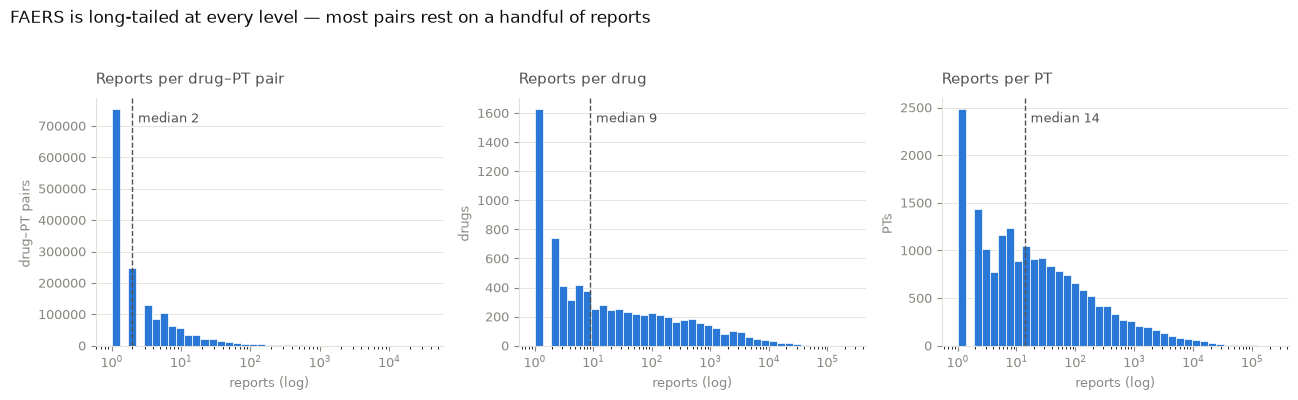

In [18]:
BLUE, INK, MUTED, GRID = "#2a78d6", "#52514e", "#898781", "#e1e0d9"

panels = [
    (per_pair, "Reports per drug–PT pair", "drug–PT pairs"),
    (per_drug, "Reports per drug",         "drugs"),
    (per_pt,   "Reports per PT",           "PTs"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (s, title, unit) in zip(axes, panels):
    bins = np.logspace(0, np.log10(s.max()), 40)
    ax.hist(s, bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)
    ax.set_xscale("log")
    #ax.set_yscale("log")

    med = s.median()
    ax.axvline(med, color=INK, linewidth=1, linestyle="--")
    ax.annotate(f"median {med:,.0f}", xy=(med, ax.get_ylim()[1]), xytext=(4, -10),
                textcoords="offset points", va="top", fontsize=9, color=INK)

    ax.set_title(title, fontsize=11, color=INK, loc="left", pad=10)
    ax.set_xlabel("reports (log)", fontsize=9, color=MUTED)
    ax.set_ylabel(f"{unit} ", fontsize=9, color=MUTED)
    ax.grid(axis="y", color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

fig.suptitle("FAERS is long-tailed at every level — most pairs rest on a handful of reports",
             fontsize=12, color="#0b0b0b", x=0.005, ha="left", y=1.04)
fig.tight_layout()
plt.show()


---
## 3. Stage 1 — Disproportionality (MGPS / EBGM)

### 3.1 The shape of the data dictates the method

The histograms above are extremely right-skewed: the median number of reports is **2** per drug–PT pair, **9** per drug, and **15** per PT. 
So the vast majority of pairs rest on **very few reports** (small `a`), and their margins `(a+b)` and `(a+c)` are small relative to `N` 
— which makes the expected count `E = (a+b)(a+c)/N` tiny, and the relative reporting ratio `RRR = a/E` explode.

What we need is an estimator that **shrinks small-count estimates toward the null — and shrinks them *more* the smaller the count.**

### 3.2 MGPS: the Multi-item Gamma-Poisson Shrinker

This is the model the FDA uses (DuMouchel 1999; see the white paper linked in §1.3). **MGPS** is the model; **EBGM** is the score it produces.

1. **Count.** For every (drug, PT) pair, take the observed count `a` and the expected count `E = (a+b)(a+c)/N` under drug–event independence.
2. **Model.** Treat `a ~ Poisson(λ·E)`, where `λ` is the pair's true reporting ratio. Put a **prior on λ**: a 2-component Gamma mixture (5 parameters — `α₁, β₁, α₂, β₂, P`), which represents a blend of "null" pairs and genuinely elevated ones.
3. **Fit the prior empirically.** Estimate those 5 hyperparameters from the representative pairs by maximum likelihood.
4. **Posterior per pair.** Combine the prior with that pair's `(a, E)` to get a posterior over `λ`:
   - **`EBGM`** — the posterior **geometric mean**. The shrunken point estimate; `EBGM ≈ 1` means "reported exactly as often as expected".
   - **`QUANT_05` (EB05)** — the posterior **5th percentile**. A conservative lower bound: "we are 95% confident the true ratio is at least this."
   - **`QUANT_95` (EB95)** — the 95th percentile.

When a pair has a large count, the data dominate the prior and `EBGM ≈ RRR`. For a small-count pair, the prior dominates and the enormous `RRR` collapses back toward 1.

### 3.3 Signal criterion

A pair is kept as a signal if:

- **`n_reports ≥ 5`**
- **`EB05 > 2`** 

`EB05 > 2` is the conventional threshold. Both criteria are deliberately **lenient here**: the goal of this project is to evaluate the *framework* that follows, so the screen is set to pass enough candidates to exercise Stages 2–4. For real screening, both would be tightened based on the observed distribution and the desired sensitivity.

### 3.4 Processing and outputs

`step1_run_ebgm.R` reads `drug_reac_pairs.csv` and fits the MGPS model via the **openEBGM** package, in four steps:

1. **Count.** `processRaw()` builds the drug × PT contingency counts — `N` (reports carrying both), `E`, `RR`, `PRR`. Every count, including the margins and the total, is a count of **distinct reports** (§2.2).
2. **Squash.** `autoSquash()` collapses ~1.7M pairs into a small set of weighted representative points, so the likelihood is tractable to optimize.
3. **Fit.** `hyperEM()` estimates the 5 hyperparameters by EM on the score equations.
4. **Score.** `ebScores()` computes each pair's posterior → `EBGM`, `QUANT_05`, `QUANT_95`.

It then applies the §3.3 filter, and writes two tables:

- **`signals.csv`** — one row per surviving pair: `prod_ai, pt, n_reports, E, RR, PRR, EBGM, QUANT_05, QUANT_95, median_suspects`. The input to Stages 2–4.
- **`unique_pts.csv`** — every distinct PT appearing in any signal. The input to Stage 2.

<br>

> EBGM's magnitude may reflect the unrestricted comparator: an event specific to one drug class (ovarian hyperstimulation syndrome, post-injection delirium sedation syndrome, scan myocardial perfusion abnormal, etc.) has a near-zero expected count against an all-drug background, so the ratio is enormous. EBGM is therefore used here for **screening and ranking, not as an effect size** — a class-restricted comparator would give more interpretable magnitudes, but would mask class-wide effects.


In [22]:
signals = pd.read_csv(config.SIGNALS_CSV)

print(f"pairs passing (n_reports >= 5 & EB05 > 2) : {len(signals):,}")
print(f"unique PTs                                : {signals.pt.nunique():,}")
print(f"unique drugs                              : {signals.prod_ai.nunique():,}")
print(f"survival rate from all drug-PT pairs      : {len(signals) / len(per_pair):.2%}")

signals.head(10)

pairs passing (n_reports >= 5 & EB05 > 2) : 177,823
unique PTs                                : 9,032
unique drugs                              : 3,523
survival rate from all drug-PT pairs      : 10.99%


,prod_ai,pt,n_reports,E,RR,PRR,EBGM,QUANT_05,QUANT_95,median_suspects
0,DOLUTEGRAVIR\LAMIVUDINE\TENOFOVIR DISOPROXIL F...,Congenital umbilical hernia,50,0.002964,16871.11,81756.16,6705.03,5277.88,8421.24,2.0
1,ATOSIBAN,Normal labour,41,0.002118,19353.51,416079.90,6195.20,4752.01,7964.75,7.0
2,CISATRACURIUM BESYLATE,Anaesthetic complication neurological,78,0.008204,9507.12,34223.03,6139.44,5074.98,7373.05,4.0
3,HUMAN CYTOMEGALOVIRUS IMMUNE GLOBULIN,Encephalitis cytomegalovirus,50,0.003913,12776.66,22757.65,5940.78,4676.30,7461.37,9.0
4,NADOFARAGENE FIRADENOVEC-VNCG,Instillation site discharge,106,0.015559,6812.85,187327.01,5280.88,4487.60,6181.05,1.0
5,TECHNETIUM TC-99M SESTAMIBI,Scan myocardial perfusion abnormal,30,0.001221,24566.31,208806.11,5230.57,3828.60,7010.58,2.0
6,PHENAZOPYRIDINE HYDROCHLORIDE,Sulphaemoglobinaemia,27,0.000926,29170.80,56328.89,4958.58,3565.87,6750.12,3.0
7,LUTROPIN ALFA,Ovarian hyperstimulation syndrome,73,0.010780,6771.85,8288.02,4770.11,3917.21,5763.49,4.0
8,TECHNETIUM TC-99M SODIUM PERTECHNETATE,Scan myocardial perfusion abnormal,24,0.000519,46266.54,157303.85,4759.63,3351.54,6599.26,2.0
9,OLANZAPINE PAMOATE,Post-injection delirium sedation syndrome,42,0.004348,9659.16,20333.96,4733.66,3642.91,6067.77,1.0


---
## 4. Stage 2 — PT triage: is this even an adverse *reaction*?

### 4.1 Why this stage exists

Stage 1 hands us a large set of statistically disproportionate (drug, PT) pairs. But a **disproportionate PT is not necessarily an adverse reaction (ADR.)** Some are — *Hepatic failure*, *Seizure* — but MedDRA is a general medical dictionary (§2.3), and reporters populate `REAC` (AEs) with whatever term describes what they saw, including *Drug ineffective* and *Off label use*. The LLM helps us extract the potential ADRs from the AEs.

### 4.2 The formal grounding: AE vs ADR (ICH E2A)

The prompt hands the model the regulatory definitions of AE and ADR from ICH E2A:

- Adverse Event (AE): any untoward medical occurrence in a patient administered a
  medicinal product that does NOT necessarily have a causal relationship with the
  treatment.
- Adverse (Drug) Reaction (ADR): a response to a medicinal product that is noxious
  and unintended, where a causal relationship with the product is at least a
  reasonable possibility.


### 4.3 The taxonomy — 7 categories, 2 kept

Every PT is assigned to exactly one category, judged **drug-agnostically**: by what the term intrinsically *is*, never by whether it is plausible for a particular drug.

| Category | Kept? | Meaning |
|---|---|---|
| **CLINICAL_EVENT** | ✅ | a genuine sign, symptom, diagnosis, or injury the patient experienced |
| **LAB_OR_INVESTIGATION** | ✅ | a test / imaging / vital-sign name or result |
| LACK_OF_EFFICACY | ❌ | treatment failure, disease progression, condition worsening |
| MEDICATION_ERROR_OR_MISUSE | ❌ | overdose, abuse, off-label use, wrong administration |
| PRODUCT_OR_DEVICE_ISSUE | ❌ | a complaint about the product or device itself |
| ADMINISTRATION_SITE_OR_ROUTE | ❌ | local reaction at the injection / application site |
| NONSPECIFIC_OR_CONTEXT | ❌ | drug-level monitoring, procedures, hospitalisation, administrative terms |

### 4.4 Processing and outputs

`step2_classify_pts.py` reads `unique_pts.csv` and classifies every distinct PT with `gpt-4.1`, one call per batch:

1. **Prompt.** Each batch is sent with the ICH E2A definitions, the goal, and the 7 category definitions and examples (built in `utils/taxonomy.py`).
2. **Parse.** Replies are matched back to the PTs verbatim.
3. **Keep.** `keep = pt_type ∈ {CLINICAL_EVENT, LAB_OR_INVESTIGATION}`.

Resumable: PTs already present in `pt_types.csv` are skipped on re-run.

It writes one table:

- **`pt_types.csv`** — `pt, pt_type, keep`. Consumed by Stage 3 as a drug-agnostic blocklist over `signals.csv`.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from utils import config, taxonomy

# ---------- (1) the actual prompt, on the 50 most common PTs ----------
top = pd.read_csv(config.UNIQUE_PTS_CSV).head(50)       # sorted by n_pairs desc
pts = top.pt.astype(str).tolist()

print(taxonomy.classification_system_prompt())
print("\n" + "=" * 78 + "\n")
print(taxonomy.classification_user_prompt(pts))


You are a senior pharmacovigilance analyst and MedDRA expert.

Definitions (ICH E2A):
- Adverse Event (AE): any untoward medical occurrence in a patient administered a
  medicinal product that does NOT necessarily have a causal relationship with the
  treatment.
- Adverse (Drug) Reaction (ADR): a response to a medicinal product that is noxious
  and unintended, where a causal relationship with the product is at least a
  reasonable possibility.
A MedDRA Preferred Term (PT) is one coded medical concept used to record what was
reported. FAERS (the FDA Adverse Event Reporting System) is a spontaneous
adverse-event reporting database, but each PT on a report is either a genuine
clinical event/reaction the patient experienced, or one of many NON-reaction
terms -- lab/test names, product or device complaints, medication errors,
procedures, and vague administrative terms.

Goal: pharmacovigilance signal detection. We want to retain only PTs that could
plausibly be a genuine adverse reaction t

In [4]:
# ---------- (2) how they came back ----------
types = pd.read_csv(config.PT_TYPES_CSV)

res = top.merge(types, on="pt", how="left")[["pt", "n_pairs", "pt_type", "keep"]]
print(f"kept {int(res.keep.sum())}/{len(res)} of the 50 most common PTs\n")
res


kept 35/50 of the 50 most common PTs



,pt,n_pairs,pt_type,keep
0,Drug ineffective,565,LACK_OF_EFFICACY,False
1,Toxicity to various agents,453,CLINICAL_EVENT,True
2,Acute kidney injury,445,CLINICAL_EVENT,True
3,Hypotension,427,CLINICAL_EVENT,True
4,Drug interaction,407,MEDICATION_ERROR_OR_MISUSE,False
5,Treatment failure,391,LACK_OF_EFFICACY,False
6,Drug ineffective for unapproved indication,368,LACK_OF_EFFICACY,False
7,Foetal exposure during pregnancy,354,NONSPECIFIC_OR_CONTEXT,False
8,Maternal exposure during pregnancy,347,NONSPECIFIC_OR_CONTEXT,False
9,Intentional overdose,340,MEDICATION_ERROR_OR_MISUSE,False


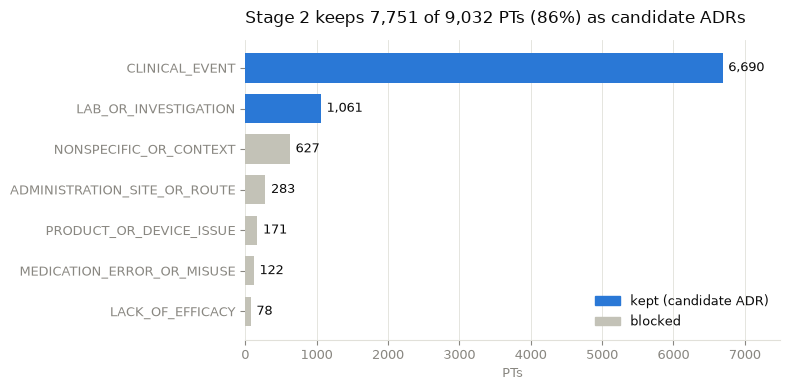

In [5]:
# ---------- (3) distribution across the 7 categories ----------
current = set(pd.read_csv(config.UNIQUE_PTS_CSV).pt.astype(str))
types   = types[types.pt.astype(str).isin(current)]

BLUE, GREY, INK, MUTED, GRID = "#2a78d6", "#c3c2b7", "#0b0b0b", "#898781", "#e1e0d9"

counts  = types.pt_type.value_counts().sort_values()
is_kept = types.groupby("pt_type")["keep"].first()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(counts.index, counts.values,
               color=[BLUE if is_kept[c] else GREY for c in counts.index], height=0.72)

for b, v in zip(bars, counts.values):
    ax.annotate(f"{v:,}", xy=(b.get_width(), b.get_y() + b.get_height() / 2),
                xytext=(4, 0), textcoords="offset points", va="center",
                fontsize=9, color=INK)

kept, total = int(types.keep.sum()), len(types)
ax.set_title(f"Stage 2 keeps {kept:,} of {total:,} PTs ({kept/total:.0%}) as candidate ADRs",
             fontsize=12, color=INK, loc="left", pad=12)
ax.set_xlabel("PTs", fontsize=9, color=MUTED)
ax.set_xlim(0, counts.max() * 1.12)
ax.grid(axis="x", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=GREY)]
ax.legend(handles, ["kept (candidate ADR)", "blocked"], frameon=False,
          fontsize=9, loc="lower right", labelcolor=INK)
fig.tight_layout()
plt.show()


---
## 5. Stage 3 — Label comparison: is it already known?

### 5.1 Where the ground truth lives — and why the *brand* matters

A drug's **FDA label** (the SPL document) is the regulatory statement of what the drug is known to do. We fetch it from the **openFDA `drug/label` endpoint** and give the model the ADR-related sections: `indications_and_usage` · `boxed_warning` · `adverse_reactions` · `warnings_and_cautions`, and so on.

But the signal is computed per **active ingredient** (Stage 0), while the **label is per product** — and in the pilot analysis we found that labels differ considerably by **route and form**, and by **manufacturer**.

Each drug is therefore pinned to **one product** for this analysis: we search on the active ingredient *and* an exact brand name, and take the most recent revision (`effective_time` descending). The **100 active ingredients** were randomly sampled from those with **20–50 significant PTs**, and each **brand name was chosen by hand** from that drug's registered brand list.

### 5.2 The classification: hierarchical, one status per AE

The model assigns each candidate AE exactly one status, in strict order:

1. **`disease_related`** — the AE is the drug's *indication*, the underlying disease, or that disease progressing → confounding by indication, not a reaction.
2. **`already_labeled`** — the label describes the AE as something the drug **can cause**, in *any* section.
3. **`novel`** — everything else. A potential **unlabeled** ADR.

### 5.3 Processing and outputs

`step3_compare_to_label.py` reads `signals.csv` and compares each drug's AEs against its label:

1. **Filter.** Keep only the PTs Stage 2 marked `keep` (`pt_types.csv`).
2. **Fetch.** `fetch_label(drug, brand)` pulls the most recent SPL for the pinned brand and extracts the ADR-related sections.
3. **Classify.** A drug's AEs go to `gpt-4.1` in one batch with the full label text; each returns one status and a one-sentence reason.

It writes one table:

- **`adr_results.csv`** — `prod_ai, pt, n_reports, EBGM, QUANT_05, status, reasoning` + the four provenance columns. The **validation set**: novel candidates *and* the known ADRs that serve as Stage 4's positive controls.


In [1]:
import pandas as pd
import step3_compare_to_label as s3
from utils import openfda

DRUG, BRAND = "FEBUXOSTAT", "ULORIC"        # exact registered string, uppercase

sig   = s3.load_signals(use_blocklist=True, drugs=[DRUG])
rows  = [{k: r[k] for k in ("prod_ai", "pt", "n_reports", "EBGM", "QUANT_05")}
         for _, r in sig.iterrows()]
label = openfda.fetch_label(DRUG, BRAND)
user  = s3.build_user_prompt(DRUG, label, rows)

print(f"{len(rows)} candidate AEs | label: {label['brand_name']} "
      f"| revision {label['effective_time']}\n")
print("=" * 78, "\nSYSTEM PROMPT\n", "=" * 78, sep="")
print(s3._SYSTEM)
print("\n" + "=" * 78, f"\nUSER PROMPT  ({len(user):,} chars — label truncated for display)\n",
      "=" * 78, sep="")
print(user[:1200])
print(f"\n   ... [ {len(user) - 2400:,} chars of label text omitted ] ...\n")
print(user[-1200:])


blocklist: kept 154041/177823 signals (7881 clinical PTs)
45 candidate AEs | label: ['ULORIC'] | revision 20251224

SYSTEM PROMPT
You are a pharmacovigilance expert comparing candidate adverse events (AEs) for ONE drug against that drug's official FDA label. The label text below is provided as reference material and may include any of the drug's sections -- indications, boxed warning, adverse reactions (narrative text and incidence tables), warnings, precautions, and contraindications. Treat the ENTIRE label as the source of truth; do not limit your search to any single section. For each AE, make a hierarchical decision and assign exactly ONE status:
1. If the AE is really the drug's INDICATION, the underlying disease being treated, or that disease worsening / the drug failing to work (so it's confounding or treatment failure, not a reaction) -> disease_related.
2. Else if the label describes the AE as something the drug can cause -- a risk, warning, or adverse experience of taking it 

In [3]:
# ---------- (2) how Stage 3 classified febuxostat ----------
feb = pd.DataFrame(s3.classify_drug(DRUG, rows, batch_size=50, brand=BRAND))

print(f"label: {feb.label_brand.iloc[0]} | {feb.label_manufacturer.iloc[0]} "
      f"| revision {feb.label_effective_time.iloc[0]}\n")
print(feb.status.value_counts().to_string(), "\n")

feb[["pt", "n_reports", "EBGM", "status", "reasoning"]].sort_values("EBGM", ascending=False)


label: ULORIC | Takeda Pharmaceuticals America, Inc. | revision 20251224

status
already_labeled    24
novel              19
disease_related     2 



,pt,n_reports,EBGM,status,reasoning
0,Cerebral artery thrombosis,10,745.97,novel,The label does not mention cerebral artery thr...
1,Gouty arthritis,8,397.84,disease_related,Gouty arthritis is the underlying disease bein...
2,Enanthema,7,397.74,novel,Enanthema is not mentioned anywhere in the lab...
3,Cerebellar infarction,10,267.65,novel,Cerebellar infarction is not listed as an adve...
4,Superinfection bacterial,10,266.47,novel,Superinfection or bacterial infection is not d...
5,Dyslipidaemia,14,104.93,already_labeled,Dyslipidaemia is covered under 'hyperlipidemia...
6,Gastric perforation,8,83.68,novel,Gastric perforation is not mentioned as an adv...
7,Cardiovascular insufficiency,5,58.41,novel,Cardiovascular insufficiency is not specifical...
8,Generalised bullous fixed drug eruption,5,46.38,novel,Generalised bullous fixed drug eruption is not...
9,Hyperlipidaemia,12,43.01,already_labeled,Hyperlipidemia is listed as an adverse reactio...


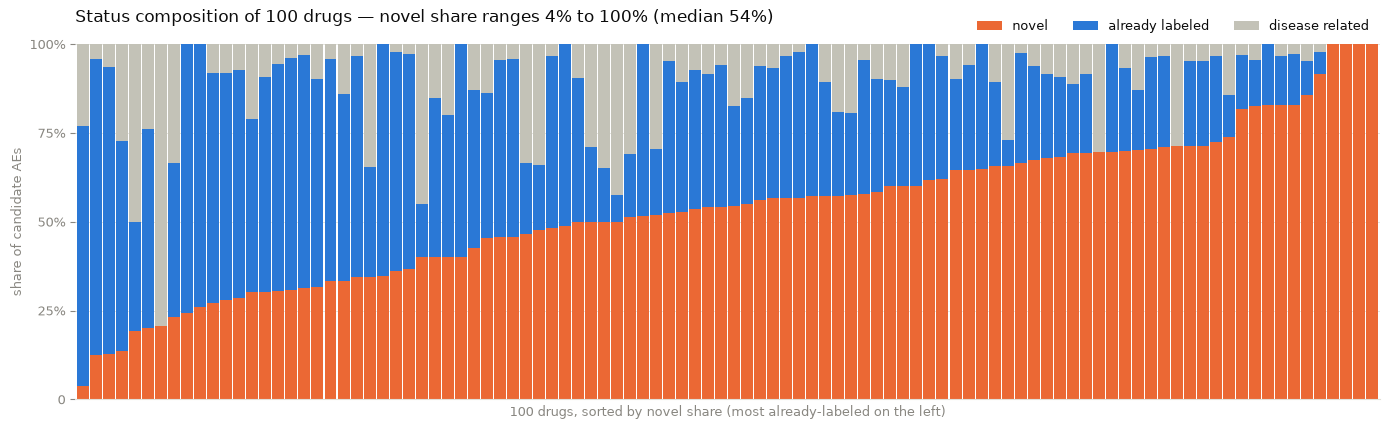

In [5]:
ORDER = ["novel", "already_labeled", "disease_related"]
COLORS = {"already_labeled": "#2a78d6", "disease_related": "#c3c2b7", "novel": "#eb6834"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

prop = res.groupby(["prod_ai", "status"]).size().unstack(fill_value=0)
for c in ORDER:
    if c not in prop:
        prop[c] = 0
prop = prop[ORDER]
prop = prop.div(prop.sum(axis=1), axis=0).sort_values("novel")   # left = most already_labeled

fig, ax = plt.subplots(figsize=(14, 4.4))
x, bottom = np.arange(len(prop)), np.zeros(len(prop))
for c in ORDER:
    ax.bar(x, prop[c], bottom=bottom, width=0.92, color=COLORS[c],
           label=c.replace("_", " "), linewidth=0)
    bottom += prop[c].values

nov = prop["novel"]
ax.set_title(f"Status composition of {len(prop)} drugs — novel share ranges "
             f"{nov.min():.0%} to {nov.max():.0%} (median {nov.median():.0%})",
             fontsize=12, color=INK, loc="left", pad=16)
ax.set_xlabel(f"{len(prop)} drugs, sorted by novel share (most already-labeled on the left)",
              fontsize=9, color=MUTED)
ax.set_ylabel("share of candidate AEs", fontsize=9, color=MUTED)
ax.set_xlim(-0.6, len(prop) - 0.4)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([0, .25, .5, .75, 1])
ax.set_yticklabels(["0", "25%", "50%", "75%", "100%"])
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)

ax.legend(frameon=False, ncols=3, fontsize=9, labelcolor=INK,
          loc="lower right", bbox_to_anchor=(1, 1.0))     # right of the title, not on top of it
fig.tight_layout()
plt.show()


---
## 6. Stage 4 — Scoring: which novel signal first?

### 6.1 Why EB05 alone is not enough for priority order

Stage 3 leaves too many novel candidates per drug, and disproportionality alone may not be enough to rank them. A **high-EB05** event can be clinically trivial. A **moderate-EB05** event can be fatal, biologically coherent with what the drug already does, and already described in a case report — and that is the one a reviewer must check first. FAERS reports are also **confounded**: a pair whose reports each carry several other suspect drugs is far weaker evidence than one whose reports carry none.

Priority is therefore necessary and a *multi-axis* question.

### 6.2 The five components

Each is normalized to **[0, 1] within a drug** (higher = more worth attention), then combined by an equally weighted sum:

| Component | Definition | Rationale |
|---|---|---|
| **`dispro`** | `log(EB05)` | the statistical signal |
| **`literature`** | max cosine(drug→PT, **cited papers**) | is there already a published case report or literature? |
| **`severity`** | max cosine(PT, **death anchors**) | a fatal event deserves more attention than a trivial one |
| **`plausibility`** | max cosine(PT, the drug's **labeled PTs + indication**) | biological coherence — and note it reuses Stage 3's `already_labeled` output as the definition of "what this drug is known to do" |
| **`low_confounding`** | `1 − log1p(median_suspects)` | fewer suspect drugs on the reports = cleaner attribution |

The three axes (literature, severity, and plausibility) are cosine similarities in the embedding space (`text-embedding-3-large`). For example:

- **`literature`** — the cosine similarity between the embedding of *"The adverse reaction of {drug} is {pt}"* and the embedding of each reference title, taking the maximum.
- **`severity`** — the cosine similarity between the PT and each of the severity anchors (e.g. death, fatal outcome, life-threatening event), taking the maximum.

**Ranking is PER DRUG.** Each component is min–max normalized within a drug and summed, giving a score between 0 and 1 — so scores are **not comparable across drugs**. The question answered is *"for THIS drug, what should I look at first?"*

### 6.3 Validation: labeled ADRs as positive controls

There is no ground-truth list of true novel ADRs. So I use the control we already have:

> Stage 4 scores **every** PT, including the `already_labeled` ones. Those are known, real ADRs — assuming the model categorized them correctly. If the score is meaningful, they must cluster near the top of each drug's ranking.

I report **lift**:

`lift@10 = precision@10 / random_precision`, where `precision@10` = labeled ADRs in the top 10 / 10, and `random_precision` = total labeled / total PTs.

**`lift > 1` means the scoring beats chance.**

### 6.4 Processing and outputs

`step4_score_pts.py` reads `adr_results.csv` and scores every AE:

1. **Embed.** PTs, the drug's labeled PTs + indication, the death anchors, and the pair's cited papers → `text-embedding-3-large`.
2. **Score.** Compute the five components and min–max normalize each *within* the drug.
3. **Combine.** Weighted sum → `final_score`; rank the PTs by `final_score` within each drug.

It writes one table:

- **`scored_adrs.csv`** — one row per (drug, PT): the five components, `final_score`, `rank`, `percentile`, plus everything carried from `adr_results.csv`.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import step4_score_pts as s4
from utils import config
import step4_score_pts as s4


BLUE, GREY, INK, MUTED, GRID = "#2a78d6", "#c3c2b7", "#0b0b0b", "#898781", "#e1e0d9"

# ---------- (1) FEBUXOSTAT, scored ----------
# `feb` is the DataFrame from the Stage 3 cell (needs `pt` + `status`)
scored_feb, _ = s4.score_drug(feb, DRUG, brand_name=BRAND)

cols = ["rank", "pt", "status", "final_score",
        "dispro", "literature", "severity", "plausibility", "low_confounding"]
scored_feb[cols].round(3)



,rank,pt,status,final_score,dispro,literature,severity,plausibility,low_confounding
0,1,Stevens-Johnson syndrome,already_labeled,0.728,0.317,1.000,0.962,0.363,1.000
1,2,Drug-induced liver injury,already_labeled,0.701,0.152,0.846,0.870,0.636,1.000
2,3,Gastric perforation,novel,0.668,0.392,0.929,0.900,0.120,1.000
3,4,Drug reaction with eosinophilia and systemic s...,already_labeled,0.645,0.230,0.632,0.894,0.469,1.000
4,5,Hyperlipidaemia,already_labeled,0.637,0.388,0.000,0.798,1.000,1.000
5,6,Hepatic function abnormal,already_labeled,0.602,0.000,0.854,0.649,0.506,1.000
6,7,Rhabdomyolysis,already_labeled,0.593,0.214,0.861,0.837,0.293,0.762
7,8,Drug eruption,already_labeled,0.590,0.253,0.832,0.804,0.469,0.593
8,9,Cardiovascular insufficiency,novel,0.588,0.247,0.430,0.977,0.286,1.000
9,10,Liver injury,already_labeled,0.549,0.108,0.000,1.000,0.636,1.000


In [5]:
# ---------- (2) lift@10: five-component score vs EB05 alone ----------
K = 10

def lift_at_k(g: pd.DataFrame, by: str, k: int = K) -> float:
    """precision@k / random_precision, ranking this drug's PTs by `by` (desc)."""
    is_lab = (g.sort_values(by, ascending=False)["status"] == "already_labeled").to_numpy()
    base = is_lab.mean()                       # random_precision = labeled / total
    return (is_lab[:k].sum() / k) / base

scored = pd.read_csv(config.SCORED_ADRS_CSV)

# keep only novel + already_labeled; drop drugs that cannot support the metric
d = scored[scored.status.isin(["novel", "already_labeled"])]
ok = d.groupby("prod_ai").filter(
    lambda g: len(g) >= K and (g.status == "already_labeled").any()
)

lift = (ok.groupby("prod_ai")
          .apply(lambda g: pd.Series({
              "n_pts":      len(g),
              "n_labeled":  int((g.status == "already_labeled").sum()),
              "lift_score": lift_at_k(g, "final_score"),
              "lift_eb05":  lift_at_k(g, "QUANT_05"),
          }), include_groups=False)
          .reset_index())

dropped = d.prod_ai.nunique() - len(lift)
print(f"drugs evaluated: {len(lift)}  (dropped {dropped}: <{K} PTs or no labeled AE)\n")
print(lift[["lift_score", "lift_eb05"]].describe().loc[["50%", "mean"]].round(2).to_string())
print(f"\nlift > 1 -- score: {(lift.lift_score > 1).mean():.0%} of drugs"
      f"  |  EB05: {(lift.lift_eb05 > 1).mean():.0%} of drugs")


drugs evaluated: 93  (dropped 7: <10 PTs or no labeled AE)

      lift_score  lift_eb05
50%          1.3       1.01
mean         1.4       0.95

lift > 1 -- score: 77% of drugs  |  EB05: 51% of drugs


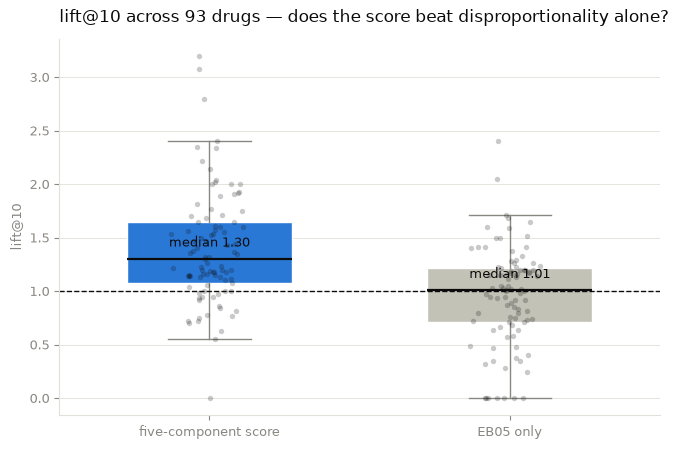

In [6]:
# ---------- the figure ----------
data = [lift.lift_score.values, lift.lift_eb05.values]

fig, ax = plt.subplots(figsize=(6.8, 4.6))
bp = ax.boxplot(data, widths=0.55, patch_artist=True, showfliers=False,
                medianprops=dict(color=INK, linewidth=1.6),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                boxprops=dict(edgecolor="white", linewidth=1))
for patch, c in zip(bp["boxes"], [BLUE, GREY]):
    patch.set_facecolor(c)

rng = np.random.default_rng(0)
for i, s in enumerate(data, start=1):
    ax.scatter(rng.normal(i, 0.055, len(s)), s, s=15, color=INK,
               alpha=0.22, zorder=3, linewidths=0)

ax.axhline(1, color=INK, linestyle="--", linewidth=1, zorder=2)
ax.annotate("lift = 1 (chance)", xy=(2.55, 1), xytext=(0, 4), textcoords="offset points",
            ha="right", fontsize=9, color=MUTED)

for i, s in enumerate(data, start=1):
    ax.annotate(f"median {np.median(s):.2f}", xy=(i, np.median(s)), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=9, color=INK)

ax.set_title(f"lift@{K} across {len(lift)} drugs — does the score beat disproportionality alone?",
             fontsize=12, color=INK, loc="left", pad=12)
ax.set_xticks([1, 2])
ax.set_xticklabels(["five-component score", "EB05 only"], fontsize=10, color=INK)
ax.set_ylabel(f"lift@{K}", fontsize=9, color=MUTED)
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)
fig.tight_layout()
plt.show()


---
## 7. Conclusion & limitations

### 7.1 What was built

An end-to-end pipeline that turns raw FAERS reports into a **per-drug, prioritised shortlist of potentially unlabeled adverse drug reactions**:

> **FAERS reports** → *(Stage 1, statistics)* **disproportionate pairs** → *(Stage 2, LLM)* **genuine clinical events** → *(Stage 3, LLM + FDA label)* **not already known** → *(Stage 4, embeddings)* **ranked by severity, biology, literature, and cleanliness of evidence**

Each stage discards signal that the next stage would have wasted attention on, and — critically — **every stage is auditable**: a per-AE `reasoning` sentence, the exact label (brand, manufacturer, revision date) it was judged against, and five separately-inspectable score components.

**The validation argument:** known ADRs, scored by the same pipeline with no knowledge that they are known, rise to the top of each drug's ranking (lift > 1). The novel events that rank *alongside them* are the ones worth a human's time.

### 7.2 Limitations

**On the LLM stages**
- **No evaluation of the label-comparison step.** There is no LLM-as-judge, no second model, no human adjudication, and no gold standard for `novel` vs `already_labeled`. A hallucinated "not on the label" is indistinguishable from a discovery.
- **Label truncation.** Each section is capped (e.g. `adverse_reactions` at 20k chars). Text past the cap is never seen by the model, and an AE described only in the dropped tail comes back as a false `novel`. The pipeline logs every truncation, but does not solve it.

**On the label comparison**
- **Drug form and route are only partially handled.** Oral / IM depot / subcutaneous / patch / topical / infusion products of the same molecule carry different labels, and brand pinning is currently a **manual** curation step.
- **Hindsight leakage.** We always compare against the **newest** SPL, but the FAERS reports are historical. An event that was genuinely novel when reported may have been added to the label since — so the pipeline scores it `already_labeled` and *destroys its own true positive*. (Medroxyprogesterone–meningioma is exactly this case: a real signal, labeled only after the 2024 evidence.) Comparing report date against `label_effective_time` would fix this and is not yet done.

**On the statistics**
- **EBGM prior fitting can be unstable**, and the results are sensitive to the prior specification. No stratification (by age, sex, report year) is applied; sensitivity analysis is only partial.
- Disproportionality **cannot** address notoriety bias, indication bias, or duplicate reporting.

**On the scoring**
- **Weights are equal and unvalidated.** There is no tuning of the five components against any outcome.
- **Literature evidence is limited to citations already present in FAERS reports** — not a live PubMed search. Absence of a citation is treated as absence of evidence, which it is not.
- `plausibility` is anchored on the drug's labeled ADRs, which **biases toward events similar to known ones** — arguably the exact opposite of what novel-signal detection wants. A truly unexpected ADR is *penalised* by this axis.

### 7.3 Where it goes next

1. **Evaluate the LLM stages** — human adjudication on a sample, inter-rater agreement, an independent model as judge.
2. **Time-aware labels** — compare each report against the SPL revision that was *current when it was filed*, turning the hindsight problem into a **backtest**: can the pipeline rediscover ADRs that were added to labels in 2024–2025, using only pre-2024 data? *(That is the strongest validation available, and MPA–meningioma is the worked example.)*
3. **Live literature retrieval** — PubMed search per (drug, PT) rather than relying on citations that happen to be attached to reports.
4. **Explicit biological reasoning** — drug target / mechanism / pathway, rather than embedding proximity as a proxy for plausibility.
5. **Handle form and route properly** — automatic product resolution from the route recorded in the FAERS `DRUG` table, instead of manual brand curation.
6. **Calibrate the score** against known post-marketing label changes.

---
## 7. Discussion

### 7.1 What was built

An end-to-end pipeline that turns raw FAERS reports into a **per-drug, prioritized shortlist of potentially unlabeled ADRs**:

> **FAERS reports** → *(Stage 1, statistics)* **disproportionate pairs** → *(Stage 2, LLM)* **genuine clinical events** → *(Stage 3, LLM + FDA label)* **not already known** → *(Stage 4, embeddings)* **ranked by severity, biology, literature, and confounding**

Every stage is **auditable**: a one-sentence `reasoning` per AE, the exact label (brand, manufacturer, revision) it was judged against, and five separately inspectable score components.

**The validation argument:** known ADRs, scored with no knowledge that they are known, rise to the top of each drug's ranking (lift > 1) and the scoring system looks better than using only EB05. The novel events that rank *alongside them* are the ones worth a reviewer's time.

### 7.2 Limitations & future work

** FAERS report ** I restricted FAERS report with reported suspect drugs less than 10 to alleviated the confounding effect but it is heuristic and not remove entirely. Also, It would be preferred to consider more product information e.g. routes to get potential AE through statisticla model if available

**EBGM** calculation seems not to be robust especially when estimating parameres of priors on \lambda. with the sensitivity analysis with drugs and PTs with large amount of report shows convergence and similar lamda parameter estimation though.

**The LLM stages are unevaluated.** There is no robust evaluation of LLM stages (step 2 & step 3). e.g. whether already_labeled PTs are actually listed in label. So LLM evaluation is neccessary


**The score is untuned.** Equal weights, never calibrated, so it can be learned from the data. Also, metrics like literature, plausibility, and severety are only measured using the information in FAERS reports using by simply measuring the similarity in sementic embedding. those can be further calibrated using external data and LLM as well. e.g. automated pubmed search to find literature evidence to connect drugs and ADR.


---
## 7. Discussion

### 7.1 What was built

An end-to-end pipeline that turns raw FAERS reports into a **per-drug, prioritized shortlist of potentially unlabeled ADRs**:

> **FAERS reports** → *(Stage 1, statistics)* **disproportionate pairs** → *(Stage 2, LLM)* **genuine clinical events** → *(Stage 3, LLM + FDA label)* **not already known** → *(Stage 4, Scoring)* **ranked by severity, biology, literature, and confounding**

**The validation argument:** known ADRs, scored with no knowledge that they are known, rise to the top of each drug's ranking (lift > 1), and the five-component score outperforms EB05 alone. The novel events that rank *alongside them* are the ones worth a reviewer's time.

### 7.2 Limitations & future work

**FAERS reports.** We restricted the analysis to reports listing no more than 10 suspect drugs, which alleviates the confounding effect but is a heuristic and does not remove it entirely. It would also be preferable to incorporate more product information — the route of administration, for example — into the statistical model where available.

**EBGM.** The estimation does not appear to be robust, particularly when fitting the prior hyperparameters on λ. A sensitivity analysis restricted to drugs and PTs with large report counts did, however, converge to similar λ estimates.

**The LLM stages are unevaluated.** There is no robust evaluation of Stages 2 and 3 — for example, whether the `already_labeled` PTs really do appear in the label. An evaluation of the LLM output is necessary.

**The score is untuned.** Equal weights, never calibrated; they could instead be learned from the data. The literature, plausibility, and severity components are also computed only from information already in the FAERS reports, by simple cosine similarity in the embedding space. These could be improved with external data and further LLM use — for example, an automated PubMed search for literature linking a drug to an ADR.


In [ ]:
# [7] TODO -- the closing slide
#   - the funnel, one line per stage:
#       pairs -> EB05>=2 -> clinical PTs -> label-compared -> novel -> priority shortlist
#     (same figure as [1]; showing it again at the end closes the loop)
#   - THE headline example: one drug, one novel PT, with its five component scores
#     and the reason it outranks that drug's median known ADR